In [2]:
import pandas as pd

In [3]:
cd = pd.read_csv("olist_customers_dataset.csv") 
gd=pd.read_csv("olist_geolocation_dataset.csv")
ot=pd.read_csv("olist_order_items_dataset.csv")
od=pd.read_csv("olist_orders_dataset.csv")
pyd=pd.read_csv("olist_order_payments_dataset.csv")
ord=pd.read_csv("olist_order_reviews_dataset.csv")
odd=pd.read_csv("olist_orders_dataset.csv")
prd=pd.read_csv("olist_products_dataset.csv")
osd=pd.read_csv("olist_sellers_dataset.csv")
pcn=pd.read_csv("product_category_name_translation.csv")

📊 Business Request: Understand Customer Spending Behavior

In [4]:
ot['revenue'] = ot['price'] + ot['freight_value']
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [5]:
# Average order value
order_value = ot.groupby('order_id')['revenue'].sum()
average_order_value = order_value.mean()
print(round(average_order_value, 2))

160.58


In [6]:
# Typical order value
typical_order_value = order_value.median()
print(round(typical_order_value, 2))

105.29


high_value_customers


In [7]:
order_value.reset_index()

,order_id,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,343.40
98662,fffcd46ef2263f404302a634eb57f7eb,386.53
98663,fffce4705a9662cd70adb13d4a31832d,116.85
98664,fffe18544ffabc95dfada21779c9644f,64.71


In [8]:
customer_order=od[['order_id','customer_id']].merge(ot,how='left',on='order_id')

In [9]:
customer_order

,order_id,customer_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62
...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,1.0,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,195.00
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,1.0,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,271.01
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,1.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,2.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,220.58


In [10]:
high_value_customers = (
    customer_order
    .groupby(['order_id', 'customer_id'])
    .agg(
        total_revenue=('revenue', 'sum'),
        total_orders=('order_id', 'count'),
        average_order_value=('revenue', 'mean')
    )
    .reset_index()
)

In [11]:
high_value_customers.sort_values(by='total_revenue', ascending=False).head(10)

,order_id,customer_id,total_revenue,total_orders,average_order_value
1471,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.08,8,1708.01
44830,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,7274.88,4,1818.72
3156,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,6929.31,1,6929.31
99072,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,6922.21,1,6922.21
95187,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,1,6726.66
17255,2cc9089445046817a7539d90805e6e5a,05455dfa7cd02f13d132aa7a6a9729c6,6081.54,6,1013.59
65576,a96610ab360d42a2e5335a3998b4718a,df55c14d1476a9a3467f131269c2477f,4950.34,1,4950.34
70098,b4c4b76c642808cbe472a32b86cddc95,e0a2412720e9ea4f26c1ac985f6a7358,4809.44,2,2404.72
9941,199af31afc78c699f0dbf71fb178d4d4,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34,1,4764.34
54793,8dbc85d1447242f3b127dda390d56e19,3d979689f636322c62418b6346b1c6d2,4681.78,1,4681.78


## Is spending consistent?

In [12]:
#Mean vs Median
if average_order_value < typical_order_value:
    print("Spending is fairly consistent")
elif average_order_value > typical_order_value:
    print("A few expensive orders are pulling the average up")
else:
    print("Spending is fairly consistent")

A few expensive orders are pulling the average up


In [13]:
#Standard Deviation
#Do customers have similar average spending habits?
standard_deviation = high_value_customers['average_order_value'].std()
standard_deviation

198.22662837407265

In [14]:
#Is customer spending consistent per order?
customer_standard_deviation = high_value_customers['total_revenue'].std()
customer_standard_deviation 

220.05880401249078

CV	Interpretation
< 25%	Very consistent
25–50%	Fairly consistent
50–100%	High variation
> 100%	Very high variation / highly inconsistent

In [15]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.44597338037697


In [16]:
#Coefficient of Variation (CV)
print((standard_deviation/average_order_value)*100)

123.44597338037697


Conclution:
Customer spending is highly inconsistent. The coefficient of variation is 123%, meaning the variation in order values exceeds the average order value. This suggests that while many customers place relatively small orders, a smaller group of customers places much larger orders, resulting in a wide spread of spending.

📊 Business Request: Identify Unusual Transactions

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
high_value_customers

,order_id,customer_id,total_revenue,total_orders,average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,218.04,1,218.04
...,...,...,...,...,...
99436,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,343.40,1,343.40
99437,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,386.53,1,386.53
99438,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,116.85,1,116.85
99439,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,64.71,1,64.71


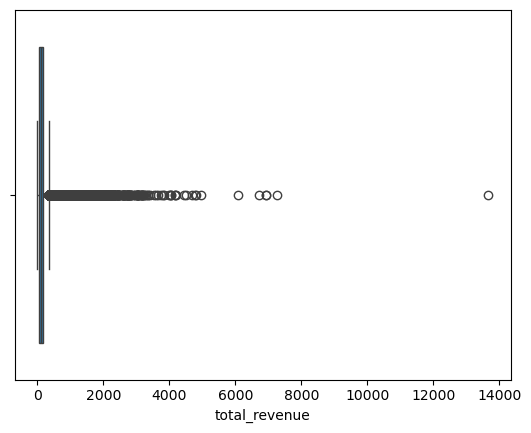

In [19]:
sns.boxplot(x=high_value_customers['total_revenue'])
plt.show()

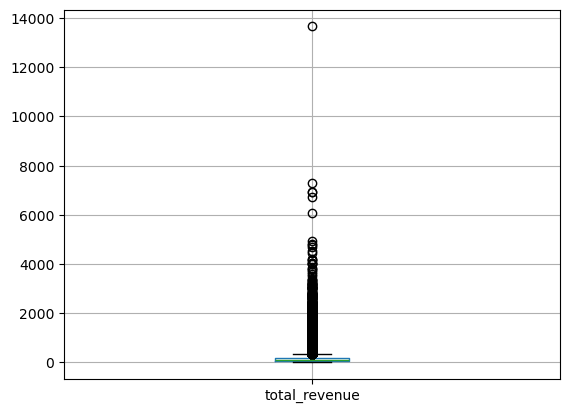

In [20]:
high_value_customers.boxplot(column='total_revenue')
plt.show()

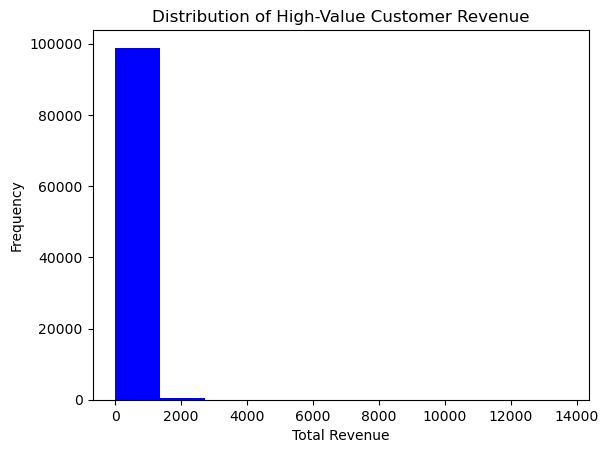

In [21]:
plt.hist(high_value_customers['total_revenue'],color='blue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')
plt.title('Distribution of High-Value Customer Revenue')
plt.show()

Histogram conlusiton: The first bar (left side) is extremely tall, while almost all other bars are very small.

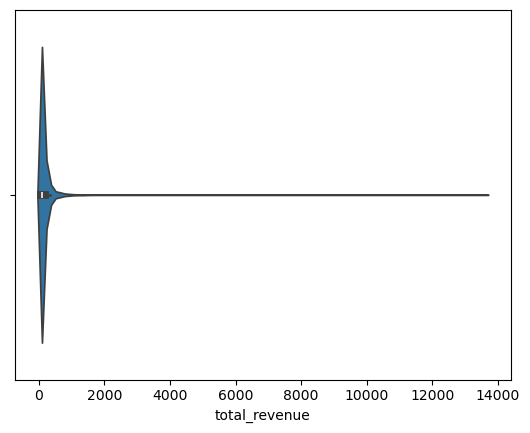

In [22]:
sns.violinplot(x=high_value_customers['total_revenue'])
plt.show()

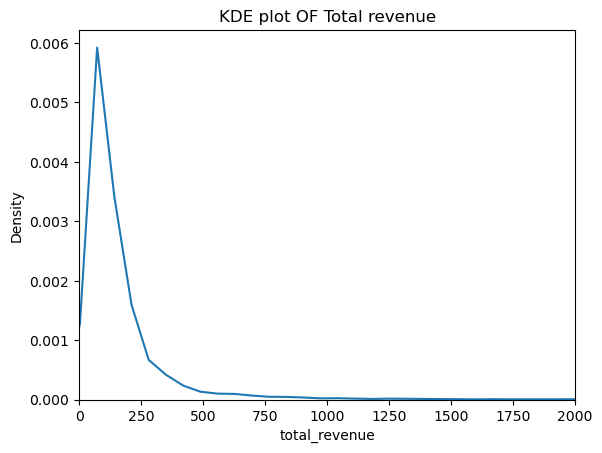

In [23]:
sns.kdeplot(data=high_value_customers['total_revenue'])
plt.title("KDE plot OF Total revenue")
plt.xlim(0,2000)
plt.show()


Extremely right-skewed

### 📊 Business Request: Identify Relationships Between Variables

In [24]:
''' Questions
-Does higher payment value lead to higher review scores?
-Does longer delivery time reduce customer ratings?
-Does freight cost increase with product weight? '''

' Questions\n-Does higher payment value lead to higher review scores?\n-Does longer delivery time reduce customer ratings?\n-Does freight cost increase with product weight? '

In [25]:
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


In [26]:
review_data = (
    ot.groupby(['order_id', 'product_id'])
      .agg(total=('price', 'sum'))
      .reset_index()
      .merge(prd[['product_id', 'product_category_name']], on='product_id', how='left')
)

In [27]:
review_data=review_data.merge(ord[['order_id', 'review_score']], on='order_id', how='left')

In [28]:
review_data

,order_id,product_id,total,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim,5.0
...,...,...,...,...,...
103022,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas,5.0
103023,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios,5.0
103024,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer,5.0
103025,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios,5.0


In [29]:
pivot=pd.pivot_table(
    review_data,
    index='product_category_name',
    columns='review_score',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

In [30]:
new = (
    review_data.groupby("product_category_name")
    .agg(
        review_count=("review_score", "count"),
        average_review=("review_score", "mean"),
        total_sales=("total", "sum"),
        average_price=("total", "mean")
    )
    .reset_index()
)

In [31]:
new

,product_category_name,review_count,average_review,total_sales,average_price
0,agro_industria_e_comercio,183,4.027322,72530.47,396.341366
1,alimentos,448,4.270089,29393.41,64.886115
2,alimentos_bebidas,235,4.395745,15270.47,64.705381
3,artes,200,4.025000,24202.64,119.815050
4,artes_e_artesanato,24,4.125000,1814.01,75.583750
...,...,...,...,...,...
68,sinalizacao_e_seguranca,141,4.092199,21509.23,150.414196
69,tablets_impressao_imagem,77,4.155844,7528.41,95.296329
70,telefonia,4259,3.984269,323839.40,75.451864
71,telefonia_fixa,215,3.902326,59622.99,273.499954


In [32]:
corr=new.corr(numeric_only=True)

In [33]:
corr



,review_count,average_review,total_sales,average_price
review_count,1.000000,0.032421,0.957486,-0.106046
average_review,0.032421,1.000000,0.034783,-0.019335
total_sales,0.957486,0.034783,1.000000,0.018028
average_price,-0.106046,-0.019335,0.018028,1.000000


<Axes: >

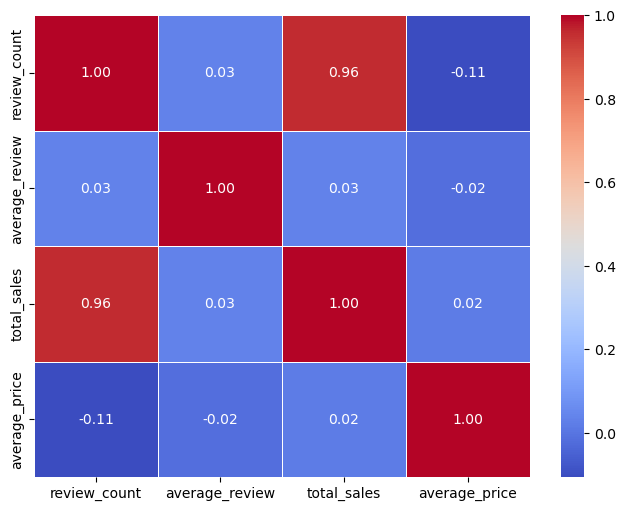

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)

'''
Correlation	Meaning
+1	Perfect positive relationship
0.7 to 0.9	Strong positive
0.3 to 0.7	Moderate positive
0	No relationship
-0.3 to -0.7	Moderate negative
-0.7 to -1	Strong negative
'''

### high value data frame

In [35]:
corr=high_value_customers.corr(numeric_only=True)

In [36]:
corr

,total_revenue,total_orders,average_order_value
total_revenue,1.000000,0.190205,0.924475
total_orders,0.190205,1.000000,-0.058466
average_order_value,0.924475,-0.058466,1.000000


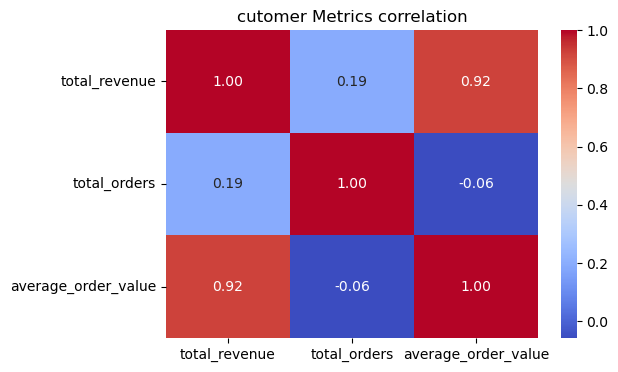

In [40]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("cutomer Metrics correlation")
plt.show()

Does longer delivery time reduce customer ratings?

In [60]:
order_review=odd.copy

In [61]:
order_review()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [71]:
# Convert timestamp columns to datetime
odd['order_purchase_timestamp'] = pd.to_datetime(odd['order_purchase_timestamp'])
odd['order_estimated_delivery_date'] = pd.to_datetime(odd['order_estimated_delivery_date'])

# Calculate delivery time in days
odd['estimated_delivery_days'] = (odd['order_estimated_delivery_date'] - odd['order_purchase_timestamp']).dt.days

# Display the result
order_review_time=odd[['order_id', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'estimated_delivery_days']].head(10)

In [72]:
ord

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [74]:
order_review_time = order_review_time.merge(
    ord[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

In [75]:
order_review_time 

,order_id,order_purchase_timestamp,order_estimated_delivery_date,estimated_delivery_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-18,15,4
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-13,19,4
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-09-04,26,5
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-15,26,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-26,12,5
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-08-01,22,4
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11 12:22:08,2017-05-09,27,2
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-06-07,21,5
8,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-03-06,41,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-23,24,5


In [81]:
corr_review =order_review_time.corr(numeric_only=True)

<Axes: >

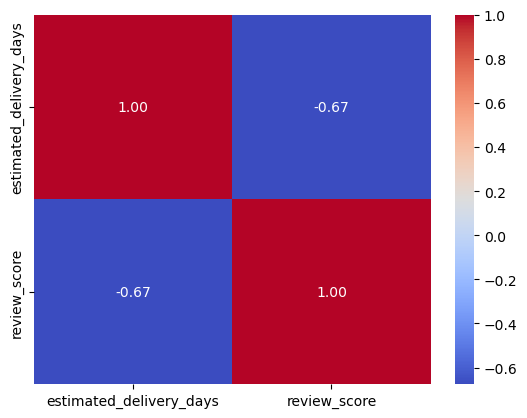

In [82]:
sns.heatmap(corr_review ,annot=True,cmap='coolwarm',fmt='.2f')

<Axes: xlabel='estimated_delivery_days', ylabel='review_score'>

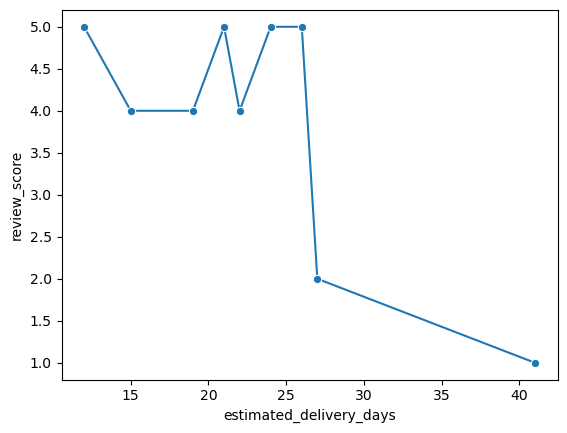

In [90]:
sns.lineplot(
    data=avg_review,
    x='estimated_delivery_days',
    y='review_score',
    marker='o'
)

In [96]:
order_review_time['delivery_group'] = pd.cut(
    order_review_time['estimated_delivery_days'],
    bins=[0,5,10,15,20,30,50],
    labels=['1-5','6-10','11-15','16-20','21-30','30+']
)

In [97]:
avg = (order_review_time
       .groupby('delivery_group')['review_score']
       .mean()
       .reset_index())

C:\Users\Vinay Chauhan\AppData\Local\Temp\ipykernel_42832\1021251528.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('delivery_group')['review_score']


<Axes: xlabel='delivery_group', ylabel='review_score'>

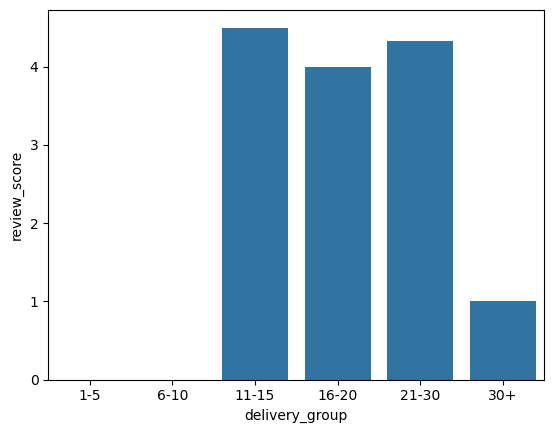

In [99]:
sns.barplot(data=avg,
            x='delivery_group',
            y='review_score')

Conclusion: Less delivery time gives higher ratings

📊 Business Request: Identify Unusual Transactions
Objective

In [110]:
high_value_customers

,order_id,customer_id,total_revenue,total_orders,average_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,72.19,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,259.83,1,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,216.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,25.78,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,218.04,1,218.04
...,...,...,...,...,...
99436,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,343.40,1,343.40
99437,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,386.53,1,386.53
99438,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,116.85,1,116.85
99439,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,64.71,1,64.71


<Axes: >

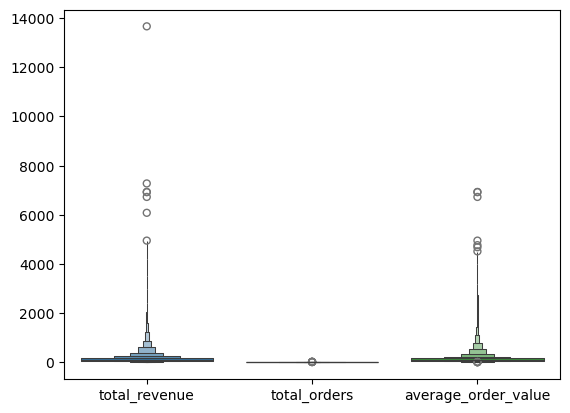

In [111]:
sns.boxenplot(high_value_customers)

In [ ]:
#Are there extremely expensive orders?
high_value_customers[high_value_customers['total_revenue']>12000]

,order_id,customer_id,total_revenue,total_orders,average_order_value
1471,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.08,8,1708.01


In [121]:
ot

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,386.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,116.85
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,64.71


<Axes: ylabel='freight_value'>

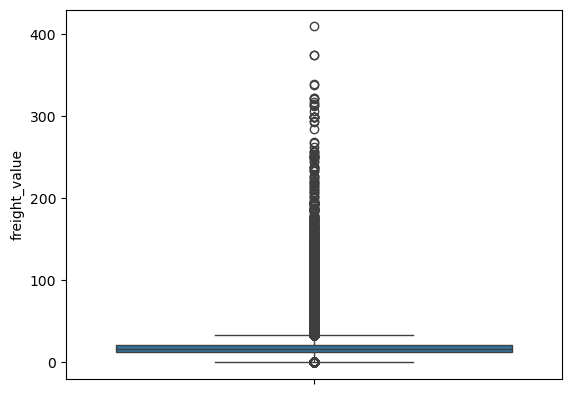

In [123]:
sns.boxplot(ot['freight_value'])

In [ ]:
Are some products significantly heavier than others?

<Axes: ylabel='product_weight_g'>

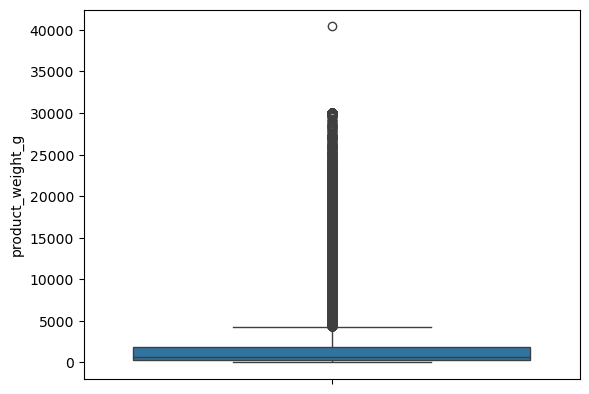

In [130]:
sns.boxplot(prd['product_weight_g'])

In [140]:
#Are some products significantly heavier than others?
products_significantly_heavier=prd[prd['product_weight_g']>40000]

In [143]:
products_significantly_heavier['product_category_name']

25166    cama_mesa_banho
Name: product_category_name, dtype: object